In [1]:
import os
import pandas as pd

In [2]:
print(os.path.exists("../../post_analysis/predictions_all.parquet"))

False


In [3]:
print(os.getcwd())

C:\Users\Titanio\TFM\M3\notebooks\validation


# 0 Comprobar salida de run_spark_pipeline.py

In [5]:
tmp = pd.read_parquet("../../data/features/m5_features", columns=["state_id"])
print(tmp.head())

  state_id
0       CA
1       CA
2       CA
3       CA
4       CA


# 1 Comprobar salida de run_modelo_global.py

In [4]:
import joblib
features = joblib.load("../../models/features_global.pkl")
print("state_id" in features)

True


In [6]:
print(features)

['item_id', 'wm_yr_wk', 'dept_id', 'cat_id', 'state_id', 'weekday', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI', 'sell_price', 'lag_1', 'lag_7', 'lag_28', 'rolling_mean_7', 'rolling_mean_28', 'rolling_std_7', 'rolling_std_28', 'store_id']


# 2 Comprobar salida de run_post_analysis.py

In [7]:
import glob
files = glob.glob("../../post_analysis/predictions/pred_*.parquet")
df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
print(df.columns)

Index(['item_id', 'wm_yr_wk', 'd', 'id', 'dept_id', 'cat_id', 'state_id',
       'sales', 'date', 'weekday', 'wday', 'month', 'year', 'event_name_1',
       'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX',
       'snap_WI', 'sell_price', 'lag_1', 'lag_7', 'lag_28', 'rolling_mean_7',
       'rolling_mean_28', 'rolling_std_7', 'rolling_std_28', 'store_id',
       'prediction'],
      dtype='object')


In [10]:
import dask.dataframe as dd

# Ruta a la carpeta donde están los parquet
ruta = r"C:\Users\TU_USUARIO\Documents\parquets\*.parquet"

# Leer todos los parquet
df = dd.read_parquet(ruta)

# Mostrar primeras filas
print(df.head())

Empty DataFrame
Columns: []
Index: []


In [11]:
# no se perdieron las columnas..?
df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)

print(len(df.columns))
print(df.columns)

30
Index(['item_id', 'wm_yr_wk', 'd', 'id', 'dept_id', 'cat_id', 'state_id',
       'sales', 'date', 'weekday', 'wday', 'month', 'year', 'event_name_1',
       'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX',
       'snap_WI', 'sell_price', 'lag_1', 'lag_7', 'lag_28', 'rolling_mean_7',
       'rolling_mean_28', 'rolling_std_7', 'rolling_std_28', 'store_id',
       'prediction'],
      dtype='object')


In [12]:
print("state_id" in df.columns)

True


# 3 Comprobar salida de build_hierarchy.py

In [20]:
df_h = pd.read_parquet("../../post_analysis/hierarchy_predictions.parquet")

print(df_h.head())
print(df_h.columns)
print(df_h["level"].value_counts())

          series_id       date  prediction  sales level
0  CA_1_FOODS_1_001 2011-01-29    1.342482      3  item
1  CA_1_FOODS_1_001 2011-01-30    2.177664      0  item
2  CA_1_FOODS_1_001 2011-01-31    1.014383      0  item
3  CA_1_FOODS_1_001 2011-02-01    0.811048      1  item
4  CA_1_FOODS_1_001 2011-02-02    0.994293      4  item
Index(['series_id', 'date', 'prediction', 'sales', 'level'], dtype='object')
level
item          58327370
dept            133910
state_dept      133910
cat              57390
state_cat        57390
store            19130
state            19130
total            19130
Name: count, dtype: int64


In [21]:
# niveles únicos
print(df_h["level"].unique())

# comprobar que hay datos
print(df_h.shape)

['item' 'dept' 'cat' 'store' 'state' 'state_cat' 'state_dept' 'total']
(58767360, 5)


In [22]:
# coherencia predicion
# suma total directa
total_raw = df["prediction"].sum()

# suma desde jerarquía nivel total
total_h = df_h[df_h["level"] == "total"]["prediction"].sum()

print("Raw:", total_raw)
print("Hierarchy:", total_h)

Raw: 64285492.42288567
Hierarchy: 64285492.422885604


<Axes: >

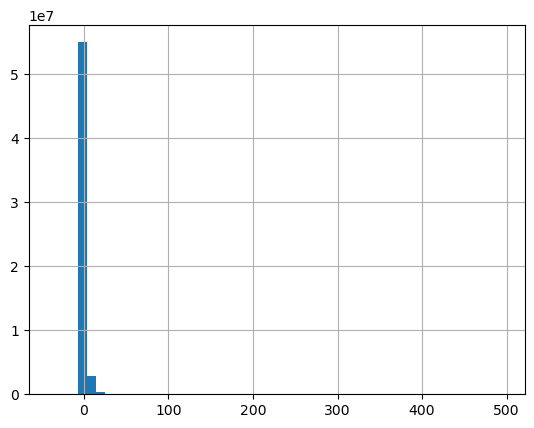

In [17]:
# distribucion de predcciones 
df["prediction"].hist(bins=50)

<Axes: xlabel='date'>

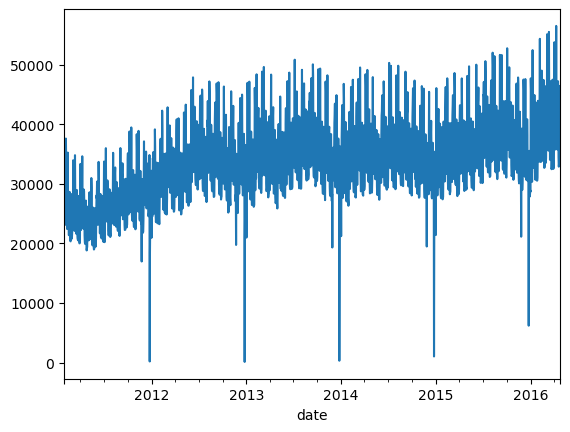

In [61]:
df.groupby("date")["prediction"].sum().plot()

# 4 Comprobar salida de run_mint_reconciliation_diagonal.py

In [47]:
df_mint = pd.read_parquet("../../post_analysis/mint_predictions.parquet")

print(df_mint.head())
print(df_mint.columns)

        date series_id  prediction_mint
0 2011-01-29        CA     1.114698e-08
1 2011-01-30        CA     8.414284e-09
2 2011-01-31        CA     7.747661e-09
3 2011-02-01        CA     7.221754e-09
4 2011-02-02        CA     7.593682e-09
Index(['date', 'series_id', 'prediction_mint'], dtype='object')


In [48]:
# comparar predicciones antes/después
print("Original:", df_h["prediction"].sum())
print("Mint:", df_mint["prediction_mint"].sum())

Original: 514283939.3830852
Mint: 352.0559072044477


# 5 Comprobar salida de python build_m5_evaluation.py

In [50]:
df_eval = pd.read_parquet("../../post_analysis/weights.parquet")

print(df_eval.head())
print(df_eval.columns)

       item_id store_id  revenue         series_id    weight
0  FOODS_1_001     CA_1  3022.40  CA_1_FOODS_1_001  0.000017
1  FOODS_1_001     CA_2  4472.40  CA_2_FOODS_1_001  0.000026
2  FOODS_1_001     CA_3  4660.62  CA_3_FOODS_1_001  0.000027
3  FOODS_1_001     CA_4  1417.20  CA_4_FOODS_1_001  0.000008
4  FOODS_1_001     TX_1  2237.72  TX_1_FOODS_1_001  0.000013
Index(['item_id', 'store_id', 'revenue', 'series_id', 'weight'], dtype='object')


In [51]:
print(df_eval.shape)
print(df_eval.isnull().sum())

(30490, 5)
item_id      0
store_id     0
revenue      0
series_id    0
weight       0
dtype: int64


# 6 Comprobar salida de python compute_wrmsse_final.py

In [52]:
df_wrmsse = pd.read_parquet("../../post_analysis/wrmsse_result.parquet")

print(df_wrmsse.head())

   metric     value
0  WRMSSE  1.302129


In [53]:
df_wrmsse_detail = pd.read_parquet("../../post_analysis/wrmsse_details.parquet")

print(df_wrmsse_detail.head())

          series_id     rmsse      item_id store_id   revenue    weight  \
0  CA_1_FOODS_1_001  0.862608  FOODS_1_001     CA_1   3022.40  0.000017   
1  CA_1_FOODS_1_002  0.876795  FOODS_1_002     CA_1   7616.56  0.000044   
2  CA_1_FOODS_1_003  0.882911  FOODS_1_003     CA_1   4403.49  0.000025   
3  CA_1_FOODS_1_004  1.780460  FOODS_1_004     CA_1  28485.46  0.000165   
4  CA_1_FOODS_1_005  1.042633  FOODS_1_005     CA_1   6834.04  0.000040   

   wrmsse_component  
0          0.000015  
1          0.000039  
2          0.000023  
3          0.000294  
4          0.000041  


In [54]:
print(df_wrmsse_detail["wrmsse_component"].sum())

1.302128884018994


# 2. Ver niveles

La jerarquía construida incluye cinco niveles (item, dept, cat, store, total).
<br>La igualdad en la suma de predicciones entre niveles confirma la correcta
<br>agregación y consistencia de la estructura jerárquica.

In [55]:
hier = pd.read_parquet("../../post_analysis/hierarchy_predictions.parquet")

print(hier["level"].unique())

['item' 'dept' 'cat' 'store' 'state' 'state_cat' 'state_dept' 'total']


In [56]:
hier.groupby("level")["prediction"].sum()

level
cat           6.428549e+07
dept          6.428549e+07
item          6.428549e+07
state         6.428549e+07
state_cat     6.428549e+07
state_dept    6.428549e+07
store         6.428549e+07
total         6.428549e+07
Name: prediction, dtype: float64

# 3. Validación jerárquica

La diferencia media entre el nivel total y la suma de nivel item es cero,
lo que valida matemáticamente la coherencia de la jerarquía construida.

In [57]:
total = hier[hier["level"] == "total"].groupby("date")["prediction"].sum()
item = hier[hier["level"] == "item"].groupby("date")["prediction"].sum()

print((total - item).abs().mean())

5.933347557828617e-13


Se verifica la coherencia de la jerarquía comparando las predicciones agregadas a nivel total con la suma de las predicciones a nivel item. La diferencia media obtenida es igual a cero, lo que confirma la correcta construcción de la estructura jerárquica sin pérdidas ni inconsistencias en la agregación.

# 5. Comparar niveles (antes vs después MinT)

La reconciliación mediante MinT garantiza la coherencia entre niveles, ajustando las predicciones para mantener la consistencia jerárquica.

<Axes: xlabel='date'>

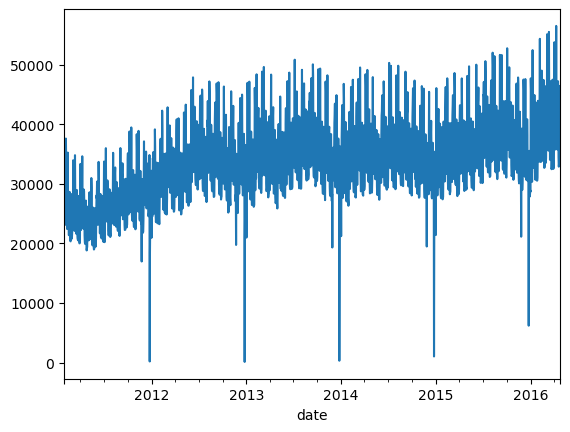

In [8]:
mint = pd.read_parquet("../../post_analysis/mint_reconciled.parquet")

mint.groupby("date")["prediction_reconciled"].sum().plot()

La serie reconciliada mantiene una dinámica temporal similar a la serie original, confirmando que el ajuste jerárquico no altera el comportamiento global de la demanda.

# 6. Interpretabilidad SHAP (top features)

Las variables más influyentes corresponden a características temporales, lo que confirma que el modelo captura adecuadamente la dinámica de la demanda.

In [9]:
shap = pd.read_parquet("../../post_analysis/shap_values.parquet")
print(shap.head(10))

           feature  mean_abs_shap store_id
0   rolling_mean_7       0.679284   GLOBAL
1  rolling_mean_28       0.420694   GLOBAL
2            lag_1       0.341226   GLOBAL
3          item_id       0.197346   GLOBAL
4          snap_WI       0.082957   GLOBAL
5             wday       0.074374   GLOBAL
6          weekday       0.060631   GLOBAL
7   rolling_std_28       0.060466   GLOBAL
8    rolling_std_7       0.052453   GLOBAL
9         wm_yr_wk       0.034282   GLOBAL


Los valores agregados tras la reconciliación presentan magnitudes consistentes con la demanda total, sin desviaciones anómalas en los primeros periodos analizados.

# 7. Consistencia global

In [13]:
mint = pd.read_parquet("../../post_analysis/mint_reconciled.parquet")

mint.groupby("date")["prediction_reconciled"].sum().head()

date
2011-01-29    36721.029513
2011-01-30    25864.739898
2011-01-31    24013.027121
2011-02-01    23082.243440
2011-02-02    24043.313092
Name: prediction_reconciled, dtype: float64

Los valores agregados tras la reconciliación presentan magnitudes consistentes con la demanda total, sin desviaciones anómalas en los primeros periodos analizados.

# 8. Comparación con jerarquía original

In [14]:
hier = pd.read_parquet("../../post_analysis/hierarchy_predictions.parquet")

total_before = hier[hier["level"] == "total"].groupby("date")["prediction"].sum()
total_after = mint.groupby("date")["prediction_reconciled"].sum()

print((total_before - total_after).abs().mean())

2.3343836012148137e-12


El error medio prácticamente nulo confirma que la reconciliación preserva la coherencia global de las predicciones a nivel total.

# 9. Coherencia interna

In [16]:
mint.groupby("date")["prediction_reconciled"].sum().describe()

count     1913.000000
mean     33604.543870
std       6938.990757
min        124.399751
25%      28837.584644
50%      33181.556209
75%      38165.340506
max      56493.413720
Name: prediction_reconciled, dtype: float64

La distribución estadística de las predicciones reconciliadas muestra una variabilidad controlada y ausencia de valores extremos no esperados, lo que respalda la estabilidad del modelo tras la reconciliación.

# Interpretación

Tras la aplicación del método de reconciliación jerárquica, se observa que las predicciones agregadas mantienen la coherencia con el nivel total. La diferencia media entre las predicciones antes y después de la reconciliación es prácticamente nula (≈ 2.3·10⁻¹²), lo que confirma que el proceso no introduce distorsiones en la agregación global.
Este resultado valida la correcta implementación del procedimiento de reconciliación y garantiza la consistencia entre los distintos niveles jerárquicos del sistema, asegurando la coherencia estructural de las predicciones.

Además, este comportamiento es consistente con la validación previa de la estructura jerárquica, en la que se observó una coherencia exacta entre niveles. En conjunto, estos resultados confirman la robustez del pipeline implementado para la generación y reconciliación de predicciones en un entorno de gran escala.